# Глава 8. Фильтрация и свёртка

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from scipy.signal.windows import gaussian as scipy_gaussian
except Exception:
    scipy_gaussian = None

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (8, 4)


In [2]:
def decorate(**options):
    xlabel = options.pop('xlabel', None)
    ylabel = options.pop('ylabel', None)
    title = options.pop('title', None)
    xlim = options.pop('xlim', None)
    ylim = options.pop('ylim', None)
    xscale = options.pop('xscale', None)
    yscale = options.pop('yscale', None)
    legend = options.pop('legend', True)
    grid = options.pop('grid', True)

    if xlabel: plt.xlabel(xlabel)
    if ylabel: plt.ylabel(ylabel)
    if title: plt.title(title)
    if xlim is not None: plt.xlim(xlim)
    if ylim is not None: plt.ylim(ylim)
    if xscale: plt.xscale(xscale)
    if yscale: plt.yscale(yscale)
    if grid: plt.grid(True, alpha=0.3)
    if legend: plt.legend()


def gaussian_window(M, std):
    """Гауссово окно длины M, нормированное на сумму 1."""
    if scipy_gaussian is not None:
        w = scipy_gaussian(M, std=std)
    else:
        n = np.arange(M) - (M - 1) / 2
        w = np.exp(-0.5 * (n / std)**2)
    return w / w.sum()


def normalize_window(w):
    """Нормирует окно так, чтобы сумма элементов равнялась 1."""
    w = np.asarray(w, dtype=float)
    return w / w.sum()


def zero_pad(array, n):
    """Дополняет массив нулями до длины n."""
    res = np.zeros(n)
    res[:len(array)] = array
    return res


def frequency_response(window, n_fft=16384):
    """Возвращает частоты и нормированную амплитудную характеристику окна."""
    w = normalize_window(window)
    padded = zero_pad(w, n_fft)
    H = np.abs(np.fft.rfft(padded))
    if H[0] != 0:
        H = H / H[0]
    freqs = np.fft.rfftfreq(n_fft, d=1.0)  # циклы на отсчёт
    return freqs, H


def amp_to_db(amp, floor=1e-12):
    """Переводит амплитуду в дБ, защищаясь от log(0)."""
    return 20 * np.log10(np.maximum(amp, floor))


def cutoff_frequency(freqs, response, level=1/np.sqrt(2)):
    """Первая частота, где амплитуда опускается ниже заданного уровня."""
    idx = np.flatnonzero(response <= level)
    if len(idx) == 0:
        return np.nan
    return freqs[idx[0]]

## Упражнение 8.1


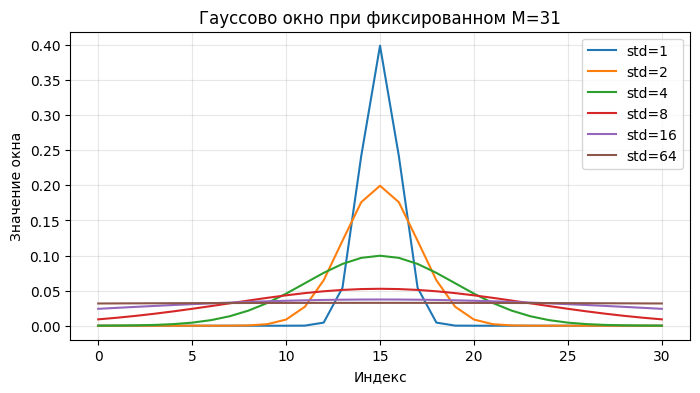

In [3]:
M = 31
std_values = [1, 2, 4, 8, 16, 64]

plt.figure(figsize=(8, 4))
for std in std_values:
    w = gaussian_window(M, std)
    plt.plot(w, label=f'std={std}')
decorate(xlabel='Индекс', ylabel='Значение окна', title=f'Гауссово окно при фиксированном M={M}')
plt.show()

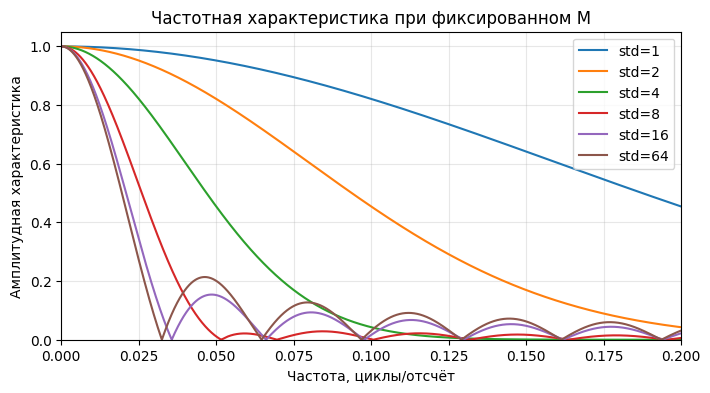

In [4]:
plt.figure(figsize=(8, 4))
for std in std_values:
    w = gaussian_window(M, std)
    freqs, H = frequency_response(w)
    plt.plot(freqs, H, label=f'std={std}')
decorate(
    xlabel='Частота, циклы/отсчёт',
    ylabel='Амплитудная характеристика',
    title='Частотная характеристика при фиксированном M',
    xlim=(0, 0.20),
    ylim=(0, 1.05)
)
plt.show()

In [5]:
rows = []
for std in std_values:
    w = gaussian_window(M, std)
    freqs, H = frequency_response(w)
    rows.append({
        'M': M,
        'std': std,
        'значение на краю / значение в центре': w[0] / w[M//2],
        'частота -3 дБ, циклы/отсчёт': cutoff_frequency(freqs, H),
    })

summary_81 = pd.DataFrame(rows)
display(summary_81)

,M,std,значение на краю / значение в центре,"частота -3 дБ, циклы/отсчёт"
0,31,1,1.386343e-49,0.132507
1,31,2,6.101937e-13,0.066284
2,31,4,8.838263e-04,0.033142
3,31,8,1.724216e-01,0.018799
4,31,16,6.443887e-01,0.015320
5,31,64,9.729079e-01,0.014404


### Вывод по упражнению 8.1

Пока `std` мал по сравнению с `M`, увеличение `std` делает окно шире, а его частотную характеристику — уже. Поэтому фильтр сильнее сглаживает сигнал и частота среза уменьшается.

Но если `M` оставить фиксированным, наступает насыщение: окно не может стать физически шире, чем заданные `M` отсчётов. При очень большом `std` все элементы гауссова окна становятся почти одинаковыми, то есть окно приближается к прямоугольному окну той же длины. Тогда дальнейшее увеличение `std` почти не улучшает сглаживание, а частотная характеристика получает боковые лепестки, характерные для прямоугольного окна.

Именно поэтому при увеличении `std` обычно нужно увеличивать и `M`, чтобы окно захватывало хвосты гауссовой кривой и не превращалось в обрезанную почти прямоугольную функцию.


In [ ]:
try:
    from ipywidgets import interact, IntSlider, FloatSlider

    def show_fixed_M_effect(M=31, std=2.0):
        w = gaussian_window(M, std)
        freqs, H = frequency_response(w)

        plt.figure(figsize=(8, 3))
        plt.plot(w, label='окно')
        decorate(xlabel='Индекс', ylabel='Значение', title=f'Окно: M={M}, std={std:.2f}')
        plt.show()

        plt.figure(figsize=(8, 3))
        plt.plot(freqs, H, label='|DFT(окна)|')
        decorate(xlabel='Частота, циклы/отсчёт', ylabel='Амплитуда', xlim=(0, 0.2), ylim=(0, 1.05))
        plt.show()

    interact(
        show_fixed_M_effect,
        M=IntSlider(min=5, max=101, step=2, value=31),
        std=FloatSlider(min=0.5, max=80, step=0.5, value=2.0)
    );
except ImportError:
    print('Для интерактивного виджета установите ipywidgets. Статические графики выше уже показывают основной эффект.')

## Упражнение 8.2


In [6]:
def centered_gaussian(N, std):
    """Гауссиана длины N с центром в середине массива."""
    n = np.arange(N) - N // 2
    g = np.exp(-0.5 * (n / std)**2)
    return g / g.sum()


def shifted_fft_magnitude(g):
    """Модуль FFT, сдвинутый так, чтобы нулевая частота была в центре."""
    N = len(g)
    H = np.fft.fftshift(np.abs(np.fft.fft(np.fft.ifftshift(g))))
    H = H / H.max()
    freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1.0))
    return freqs, H


def weighted_std(x, weights):
    """Стандартное отклонение координат x с весами weights."""
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    mean = np.sum(x * weights)
    return np.sqrt(np.sum((x - mean)**2 * weights))

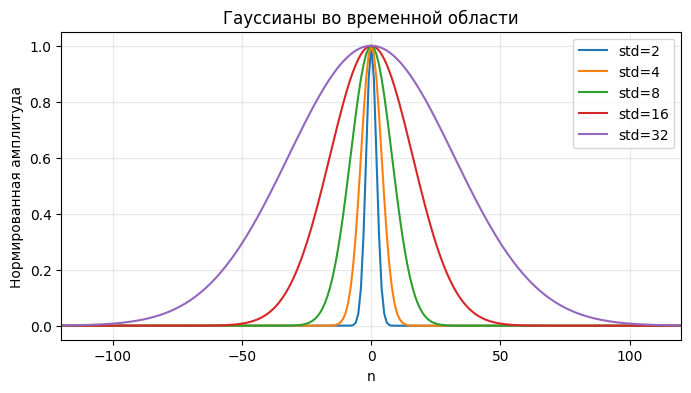

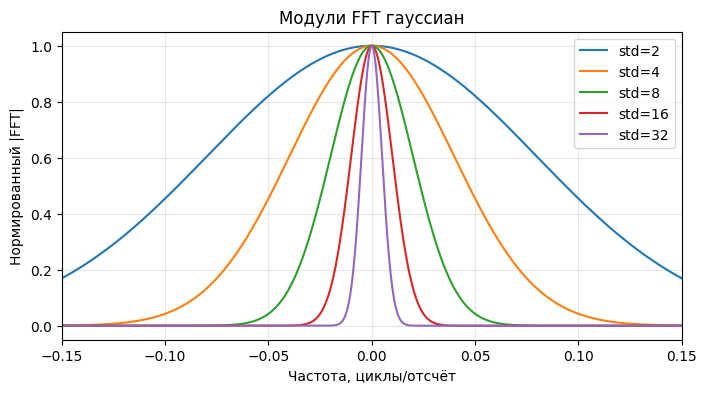

In [7]:
N = 4096
std_values_82 = [2, 4, 8, 16, 32]

plt.figure(figsize=(8, 4))
for std in std_values_82:
    g = centered_gaussian(N, std)
    n = np.arange(N) - N // 2
    plt.plot(n, g / g.max(), label=f'std={std}')
decorate(xlabel='n', ylabel='Нормированная амплитуда', title='Гауссианы во временной области', xlim=(-120, 120))
plt.show()

plt.figure(figsize=(8, 4))
for std in std_values_82:
    g = centered_gaussian(N, std)
    freqs, H = shifted_fft_magnitude(g)
    plt.plot(freqs, H, label=f'std={std}')
decorate(xlabel='Частота, циклы/отсчёт', ylabel='Нормированный |FFT|', title='Модули FFT гауссиан', xlim=(-0.15, 0.15))
plt.show()

In [8]:
rows = []
for std in std_values_82:
    g = centered_gaussian(N, std)
    freqs, H = shifted_fft_magnitude(g)
    estimated = weighted_std(freqs, H)
    theoretical = 1 / (2 * np.pi * std)
    rows.append({
        'std во времени': std,
        'оценённая std в частоте': estimated,
        '1/(2π·std)': theoretical,
        'произведение std·std_f': std * estimated,
    })

summary_82 = pd.DataFrame(rows)
display(summary_82)

,std во времени,оценённая std в частоте,1/(2π·std),произведение std·std_f
0,2,0.079577,0.079577,0.159155
1,4,0.039789,0.039789,0.159155
2,8,0.019894,0.019894,0.159155
3,16,0.009947,0.009947,0.159155
4,32,0.004974,0.004974,0.159155


### Вывод по упражнению 8.2

Графики подтверждают утверждение: модуль ДПФ гауссовой кривой тоже имеет гауссову форму, если окно достаточно длинное и хвосты гауссианы почти не обрезаются.

При увеличении `std` гауссова кривая во временной области становится шире, а её спектр становится уже. Численная таблица показывает, что произведение ширины во времени на ширину в частотной области остаётся почти постоянным и близко к $1/(2\pi)$. Это и есть обратная связь между шириной окна и шириной его частотной характеристики.


## Упражнение 8.3



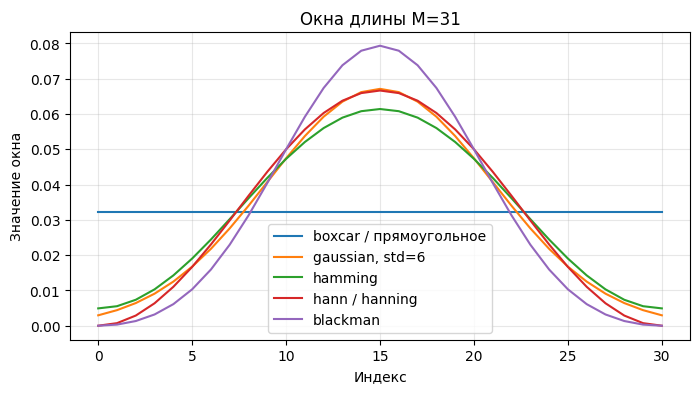

In [9]:
M = 31
std = 6
n_fft = 65536

windows = {
    'boxcar / прямоугольное': np.ones(M),
    f'gaussian, std={std}': gaussian_window(M, std),
    'hamming': np.hamming(M),
    'hann / hanning': np.hanning(M),
    'blackman': np.blackman(M),
}

# Нормируем окна, чтобы все они сохраняли постоянную составляющую сигнала.
windows = {name: normalize_window(w) for name, w in windows.items()}

plt.figure(figsize=(8, 4))
for name, w in windows.items():
    plt.plot(w, label=name)
decorate(xlabel='Индекс', ylabel='Значение окна', title=f'Окна длины M={M}')
plt.show()

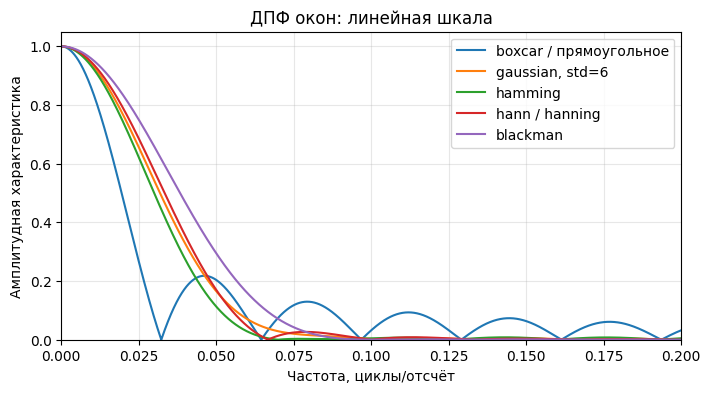

In [10]:
plt.figure(figsize=(8, 4))
for name, w in windows.items():
    freqs, H = frequency_response(w, n_fft=n_fft)
    plt.plot(freqs, H, label=name)
decorate(
    xlabel='Частота, циклы/отсчёт',
    ylabel='Амплитудная характеристика',
    title='ДПФ окон: линейная шкала',
    xlim=(0, 0.20),
    ylim=(0, 1.05)
)
plt.show()

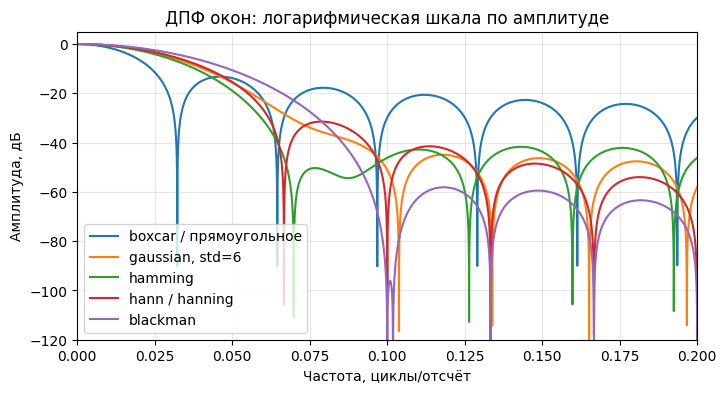

In [11]:
plt.figure(figsize=(8, 4))
for name, w in windows.items():
    freqs, H = frequency_response(w, n_fft=n_fft)
    plt.plot(freqs, amp_to_db(H), label=name)
decorate(
    xlabel='Частота, циклы/отсчёт',
    ylabel='Амплитуда, дБ',
    title='ДПФ окон: логарифмическая шкала по амплитуде',
    xlim=(0, 0.20),
    ylim=(-120, 5)
)
plt.show()

In [12]:
rows = []
for name, w in windows.items():
    freqs, H = frequency_response(w, n_fft=n_fft)
    rows.append({
        'окно': name,
        'частота -3 дБ': cutoff_frequency(freqs, H),
        'макс. амплитуда выше 0.10 циклов/отсчёт, дБ': amp_to_db(np.max(H[freqs >= 0.10])),
        'макс. амплитуда выше 0.15 циклов/отсчёт, дБ': amp_to_db(np.max(H[freqs >= 0.15])),
    })

summary_83 = pd.DataFrame(rows)
display(summary_83)

,окно,частота -3 дБ,"макс. амплитуда выше 0.10 циклов/отсчёт, дБ","макс. амплитуда выше 0.15 циклов/отсчёт, дБ"
0,boxcar / прямоугольное,0.014297,-20.608269,-23.974992
1,"gaussian, std=6",0.022736,-44.907989,-46.358158
2,hamming,0.021469,-41.703919,-42.143579
3,hann / hanning,0.024017,-41.487871,-48.726775
4,blackman,0.027405,-58.136679,-59.554817


### Вывод по упражнению 8.3
Универсального «лучшего» окна нет. Если нужен практичный НЧ-фильтр с хорошим компромиссом между шириной переходной области и боковыми лепестками, разумный выбор — `hann` или `hamming`. Если важнее сильное подавление дальних высоких частот, лучше подойдёт `blackman` или аккуратно подобранное гауссово окно. Прямоугольное окно обычно худший вариант из-за сильных боковых лепестков.
